In [91]:
import pandas as pd
import numpy as np
import seaborn as sns 

df = pd.read_csv("GHG_emissions_output_naei23 (1).csv")


In [92]:
#Understanding the data

In [93]:
df.head()

,GasID,Gas,NFR/CRT Code,NFR/CRT Description,Sourcecode,SourceName,Activitycode,ActivityName,Emission_Unit,Year,Emission
0,2,Carbon Dioxide as Carbon,1A1ai,Public electricity generation,33,Power stations,7,Coal,kilotonne,1990,49949.948922
1,2,Carbon Dioxide as Carbon,1A1ai,Public electricity generation,33,Power stations,7,Coal,kilotonne,1991,50185.842470
2,2,Carbon Dioxide as Carbon,1A1ai,Public electricity generation,33,Power stations,7,Coal,kilotonne,1992,46898.598572
3,2,Carbon Dioxide as Carbon,1A1ai,Public electricity generation,33,Power stations,7,Coal,kilotonne,1993,39044.702153
4,2,Carbon Dioxide as Carbon,1A1ai,Public electricity generation,33,Power stations,7,Coal,kilotonne,1994,36854.359195


In [94]:
df.tail()

,GasID,Gas,NFR/CRT Code,NFR/CRT Description,Sourcecode,SourceName,Activitycode,ActivityName,Emission_Unit,Year,Emission
139021,Total GHGs in CO2 Eq.,Total GHGs in CO2 Eq.,2F1d,Transport refrigeration refrigerant leakage,1165,"Transport Refrigeration: Systems for vans, lig...",372,Halocarbon in products at disposal: HFC-32,kilotonne,2019,NaN
139022,Total GHGs in CO2 Eq.,Total GHGs in CO2 Eq.,2F1d,Transport refrigeration refrigerant leakage,1165,"Transport Refrigeration: Systems for vans, lig...",372,Halocarbon in products at disposal: HFC-32,kilotonne,2020,NaN
139023,Total GHGs in CO2 Eq.,Total GHGs in CO2 Eq.,2F1d,Transport refrigeration refrigerant leakage,1165,"Transport Refrigeration: Systems for vans, lig...",372,Halocarbon in products at disposal: HFC-32,kilotonne,2021,NaN
139024,Total GHGs in CO2 Eq.,Total GHGs in CO2 Eq.,2F1d,Transport refrigeration refrigerant leakage,1165,"Transport Refrigeration: Systems for vans, lig...",372,Halocarbon in products at disposal: HFC-32,kilotonne,2022,0.001791
139025,Total GHGs in CO2 Eq.,Total GHGs in CO2 Eq.,2F1d,Transport refrigeration refrigerant leakage,1165,"Transport Refrigeration: Systems for vans, lig...",372,Halocarbon in products at disposal: HFC-32,kilotonne,2023,0.007120


In [95]:
print("Shape:", df.shape)


Shape: (139026, 11)


In [96]:
df.columns

Index(['GasID', 'Gas', 'NFR/CRT Code', 'NFR/CRT Description', 'Sourcecode',
       'SourceName', 'Activitycode', 'ActivityName', 'Emission_Unit', 'Year',
       'Emission'],
      dtype='str')

In [97]:
df.nunique()

GasID                       8
Gas                         8
NFR/CRT Code              213
NFR/CRT Description       213
Sourcecode                577
SourceName                567
Activitycode              227
ActivityName              227
Emission_Unit               2
Year                       34
Emission               101983
dtype: int64

In [98]:
df["Gas"].unique()

<ArrowStringArray>
['Carbon Dioxide as Carbon',                  'Methane',
            'Nitrous Oxide',                     'HFCs',
                      'NF3',                     'PFCs',
     'Sulphur hexafluoride',    'Total GHGs in CO2 Eq.']
Length: 8, dtype: str

In [99]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 139026 entries, 0 to 139025
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   GasID                139026 non-null  str    
 1   Gas                  139026 non-null  str    
 2   NFR/CRT Code         139026 non-null  str    
 3   NFR/CRT Description  139026 non-null  str    
 4   Sourcecode           139026 non-null  int64  
 5   SourceName           139026 non-null  str    
 6   Activitycode         139026 non-null  int64  
 7   ActivityName         139026 non-null  str    
 8   Emission_Unit        139026 non-null  str    
 9   Year                 139026 non-null  int64  
 10  Emission             113752 non-null  float64
dtypes: float64(1), int64(3), str(7)
memory usage: 29.6 MB


In [100]:
df.describe()


,Sourcecode,Activitycode,Year,Emission
count,139026.000000,139026.000000,139026.000000,113752.000000
mean,3271.142822,390.110296,2006.500000,250.407167
std,3527.434311,330.796762,9.810744,2609.937881
min,2.000000,1.000000,1990.000000,-19939.108178
25%,551.000000,21.000000,1998.000000,0.010198
50%,1156.000000,362.000000,2006.500000,0.398673
75%,8011.000000,803.000000,2015.000000,17.846529
max,8378.000000,899.000000,2023.000000,185001.296819


In [101]:
#cleaning the data

In [102]:
df.isnull().sum()  # finding the null values in dataste


GasID                      0
Gas                        0
NFR/CRT Code               0
NFR/CRT Description        0
Sourcecode                 0
SourceName                 0
Activitycode               0
ActivityName               0
Emission_Unit              0
Year                       0
Emission               25274
dtype: int64

In [103]:
df = df.dropna()  # removing the null values in the dataset


In [104]:
#Removing unwanted cols and keeping only required cols
cols_to_drop = [
    'GasID',
    'NFR/CRT Code',
    'NFR/CRT Description',
    'Sourcecode',
    'Activitycode',
    'Emission_Unit'
]

df = df.drop(columns=cols_to_drop)

In [105]:
df.head()

,Gas,SourceName,ActivityName,Year,Emission
0,Carbon Dioxide as Carbon,Power stations,Coal,1990,49949.948922
1,Carbon Dioxide as Carbon,Power stations,Coal,1991,50185.842470
2,Carbon Dioxide as Carbon,Power stations,Coal,1992,46898.598572
3,Carbon Dioxide as Carbon,Power stations,Coal,1993,39044.702153
4,Carbon Dioxide as Carbon,Power stations,Coal,1994,36854.359195


In [106]:
# Relationship between varibles

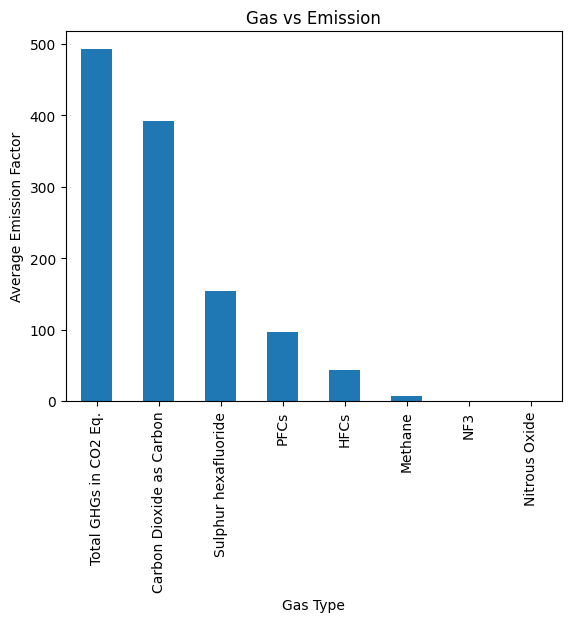

In [107]:
# ---- Gas vs Emission ----
import matplotlib.pyplot as plt
gas_emission = df.groupby('Gas')['Emission'].mean().sort_values(ascending=False)
plt.figure()
gas_emission.plot(kind='bar')
plt.xlabel("Gas Type")
plt.ylabel("Average Emission Factor")
plt.title("Gas vs Emission")
plt.show()

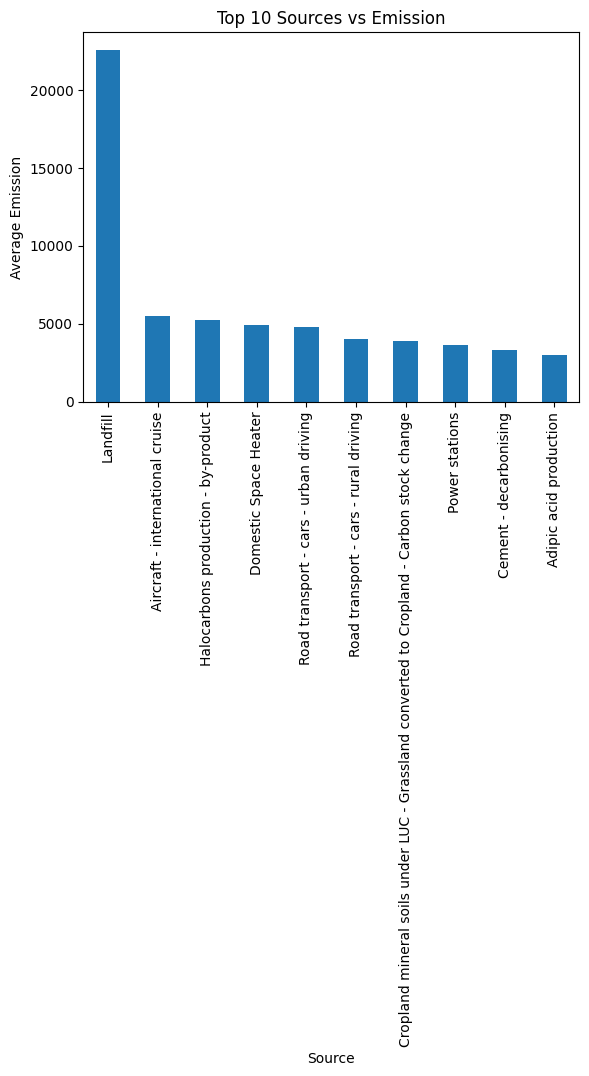

In [108]:
# ---- Source vs Emission ----
source_emission = df.groupby('SourceName')['Emission'].mean().sort_values(ascending=False).head(10)
plt.figure()
source_emission.plot(kind='bar')
plt.xlabel("Source")
plt.ylabel("Average Emission")
plt.title("Top 10 Sources vs Emission")
plt.show()

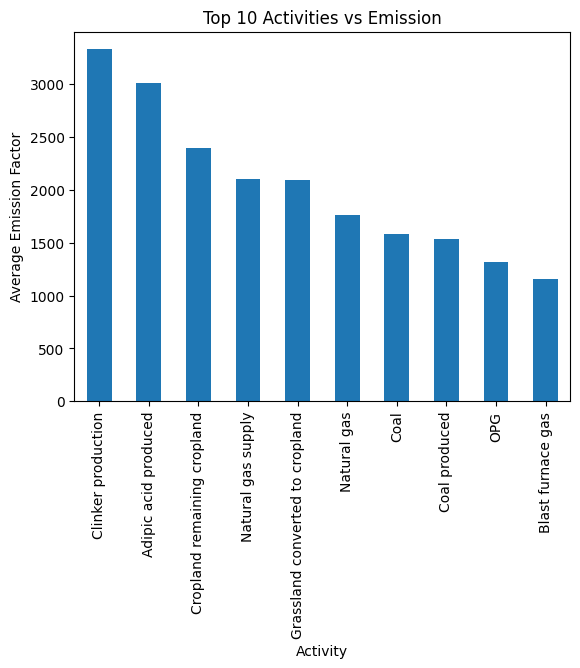

In [109]:
# ---- Activity vs Emission ----
activity_emission = df.groupby('ActivityName')['Emission'].mean().sort_values(ascending=False).head(10)
plt.figure()
activity_emission.plot(kind='bar')
plt.xlabel("Activity")
plt.ylabel("Average Emission Factor")
plt.title("Top 10 Activities vs Emission")
plt.show()

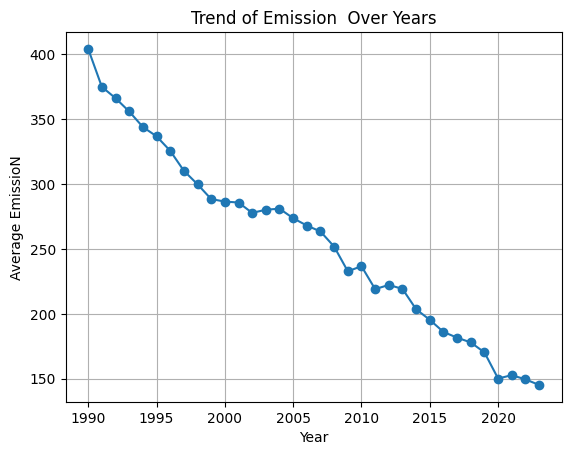

In [110]:
# ---- Year vs Emission (Trend Line) ----
year_emission = df.groupby('Year')['Emission'].mean()

plt.figure()
year_emission.plot(marker='o') 
plt.xlabel("Year")
plt.ylabel("Average EmissioN")
plt.title("Trend of Emission  Over Years")
plt.grid(True)
plt.show()


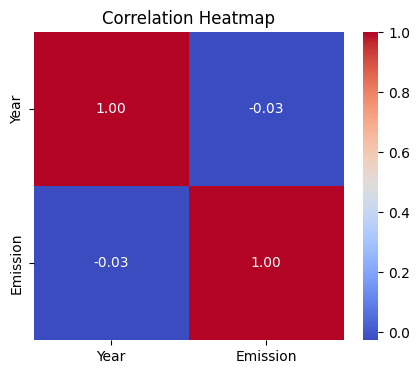

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

#numeric columns
numeric_df = df[['Year', 'Emission']]

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [112]:
#Model

In [113]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score


In [114]:
print(df.columns)

Index(['Gas', 'SourceName', 'ActivityName', 'Year', 'Emission'], dtype='str')


In [115]:
df = df[['Gas', 'SourceName','ActivityName', 'Year', 'Emission']]
df.head()

,Gas,SourceName,ActivityName,Year,Emission
0,Carbon Dioxide as Carbon,Power stations,Coal,1990,49949.948922
1,Carbon Dioxide as Carbon,Power stations,Coal,1991,50185.842470
2,Carbon Dioxide as Carbon,Power stations,Coal,1992,46898.598572
3,Carbon Dioxide as Carbon,Power stations,Coal,1993,39044.702153
4,Carbon Dioxide as Carbon,Power stations,Coal,1994,36854.359195


In [116]:
df = df.sort_values(['Gas', 'SourceName', 'ActivityName','Year'])
df.head()

,Gas,SourceName,ActivityName,Year,Emission
10098,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1990,3.084723
10099,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1991,2.382917
10100,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1992,2.763347
10101,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1993,3.598210
10102,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1994,3.743416


In [117]:
df['Previous_Emission'] = df.groupby(['Gas', 'SourceName', 'ActivityName'])['Emission'].shift(1)

df['Emission_Rise'] = (df['Emission'] > df['Previous_Emission']).astype(int)


df = df.dropna()

df.head()

,Gas,SourceName,ActivityName,Year,Emission,Previous_Emission,Emission_Rise
10099,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1991,2.382917,3.084723,0
10100,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1992,2.763347,2.382917,1
10101,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1993,3.598210,2.763347,1
10102,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1994,3.743416,3.598210,1
10103,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1995,3.734793,3.743416,0


In [118]:
le_gas = LabelEncoder()
le_sector = LabelEncoder()
le_Activity = LabelEncoder()

df['Gas_encoded'] = le_gas.fit_transform(df['Gas'])
df['Sector_encoded'] = le_sector.fit_transform(df['SourceName'])
df['Activity_encoded']= le_Activity.fit_transform(df['ActivityName'])

df.head()

,Gas,SourceName,ActivityName,Year,Emission,Previous_Emission,Emission_Rise,Gas_encoded,Sector_encoded,Activity_encoded
10099,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1991,2.382917,3.084723,0,0,13,113
10100,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1992,2.763347,2.382917,1,0,13,113
10101,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1993,3.598210,2.763347,1,0,13,113
10102,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1994,3.743416,3.598210,1,0,13,113
10103,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1995,3.734793,3.743416,0,0,13,113


In [119]:
X = df[['Gas_encoded', 'Sector_encoded', 'Activity_encoded','Year']]
y = df['Emission_Rise']

X.head(), y.head()

(       Gas_encoded  Sector_encoded  Activity_encoded  Year
 10099            0              13               113  1991
 10100            0              13               113  1992
 10101            0              13               113  1993
 10102            0              13               113  1994
 10103            0              13               113  1995,
 10099    0
 10100    1
 10101    1
 10102    1
 10103    0
 Name: Emission_Rise, dtype: int64)

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(87730, 4)
(21933, 4)


In [121]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [122]:
y_prob = model.predict_proba(X_test)[:, 1]

In [123]:
thresholds = np.arange(0.1, 0.9, 0.01)
best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    y_pred_temp = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)

Best Threshold: 0.4299999999999998


In [124]:
y_pred = (y_prob >= best_threshold).astype(int)

In [125]:
print("Best Threshold:", best_threshold)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Best Threshold: 0.4299999999999998

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.79      0.83     10716
           1       0.81      0.89      0.85     11217

    accuracy                           0.84     21933
   macro avg       0.84      0.84      0.84     21933
weighted avg       0.84      0.84      0.84     21933

ROC-AUC Score: 0.9284170109139852

Confusion Matrix:

[[8434 2282]
 [1288 9929]]
